# P&S Module 1: Measures of Central Tendency & Variability

**Week 1:**
- Lesson 1: Video 4 - Mean, Median, Mode
- Lesson 2: Video 5 - Standard Deviation and Variance

**Week 2:**
- Lesson 1: Videos 1-4 - Quartiles, Box Plots, and Outlier Detection

---

## Part A: Measures of Central Tendency & Variability

### Problem Statement

Find the mean, median, mode, standard deviation and variance for the given data:

**(i) Dataset 1:** 13, 15, 14, 10, 18, 16, 17, 14, 13, 19, 11, 12, 14, 13, 18, 16, 15, 17, 11, 12

**(ii) Dataset 2:** 19, 11, 28, 10, 13, 22, 20, 21, 25, 30, 26, 15, 23, 14, 16, 29, 24, 18, 12, 17

In [ ]:
import statistics as stats
import random
from collections import Counter

### Understanding the Measures:

**Central Tendency** - Where is the "center" of our data?
- **Mean**: The average value (sum ÷ count)
- **Median**: The middle value when data is sorted
- **Mode**: The most frequent value

**Variability** - How spread out is our data?
- **Variance**: Average of squared differences from mean
- **Standard Deviation**: Square root of variance (same units as data)

In [ ]:
# Option 1: Use your own 20 data points
data = [13, 15, 14, 10, 18, 16, 17, 14, 13, 19, 11, 12, 14, 13, 18, 16, 15, 17, 11, 12]
#data = [19, 11, 28, 10, 13, 22, 20, 21, 25, 30, 26, 15, 23, 14, 16, 29, 24, 18, 12, 17]

print("Data:", data)

# Calculations
mean = stats.mean(data)
median = stats.median(data)

frequency = Counter(data)
max_freq = max(frequency.values())

# Find all numbers that appear max_freq times
modes = [key for key, val in frequency.items() if val == max_freq]

# If all values occur only once (no repeating value)
if len(modes) == len(data):
    print("No mode found: all values occur only once.")
else:
    print(f"Mode(s): {modes}")

variance = stats.variance(data)  # Sample variance
std_dev = stats.stdev(data)      # Sample standard deviation

# Output
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Variance: {variance}")
print(f"Standard Deviation: {std_dev}")

Data: [13, 15, 14, 10, 18, 16, 17, 14, 13, 19, 11, 12, 14, 13, 18, 16, 15, 17, 11, 12]
Mode(s): [13, 14]
Mean: 14.4
Median: 14.0
Variance: 6.673684210526316
Standard Deviation: 2.583347481568501


### 📝 TO DO #1: Compare Two Datasets

1. Run the cell above with Dataset 1 (already set)
2. Comment out Dataset 1 and uncomment Dataset 2
3. Run again and compare the results

**Questions to think about:**
- Which dataset has a higher mean?
- Which dataset has more variability (higher standard deviation)?
- Why might the mode be different?

### 📝 TO DO #2: Generate Random Data

Let's see how statistics change with different random datasets:

In [ ]:
# TO DO: Change these parameters and see how statistics change

# Generate random data with normal distribution
# Change these values:
sample_size = 20        # Try: 10, 50, 100
data_mean = 15          # Try: 10, 20, 50
data_spread = 3         # Try: 1 (tight), 5 (medium), 10 (wide)

random_data = [random.gauss(data_mean, data_spread) for _ in range(sample_size)]
random_data = [round(x, 1) for x in random_data]  # Round for clarity

print(f"Generated {sample_size} random numbers:")
print(random_data[:10], "..." if sample_size > 10 else "")

print(f"\nStatistics:")
print(f"Mean: {stats.mean(random_data):.2f} (target was {data_mean})")
print(f"Std Dev: {stats.stdev(random_data):.2f} (target was {data_spread})")
print(f"Median: {stats.median(random_data):.2f}")

Generated 20 random numbers:
[8.8, 18.5, 8.6, 18.6, 17.3, 18.5, 13.8, 12.3, 17.4, 18.6] ...

Statistics:
Mean: 15.50 (target was 15)
Std Dev: 3.81 (target was 3)
Median: 17.25


---

## Part B: Understanding the Data - Quartiles, Box Plots & Outliers

### Problem Statement

Compute the values of Q1, Q2 and Q3 for the given data:
**12, 15, 14, 13, 16, 15, 14, 15, 14, 13, 100, 105**

Also, plot the histogram and box-plot to visualize the outliers.

### What are Quartiles?

Quartiles divide sorted data into 4 equal parts:
- **Q1** (25th percentile): 25% of data is below this value
- **Q2** (50th percentile): This is the median
- **Q3** (75th percentile): 75% of data is below this value
- **IQR** (Interquartile Range) = Q3 - Q1 (middle 50% of data)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# Sample data - notice the outliers (100, 105)!
data = [12, 15, 14, 13, 16, 15, 14, 15, 14, 13, 100, 105]

# Compute Quartiles
Q1 = np.percentile(data, 25)
Q2 = np.percentile(data, 50)  # Median
Q3 = np.percentile(data, 75)

# Compute Skewness
data_skewness = skew(data)

# Display results
print(f"Q1 (25th percentile): {Q1}")
print(f"Q2 (Median): {Q2}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Q3 - Q1): {Q3 - Q1}")
print(f"\nSkewness: {data_skewness:.3f}")
print("Interpretation:",
      "Right-skewed (positive)" if data_skewness > 0.5 else
      "Left-skewed (negative)" if data_skewness < -0.5 else
      "Approximately symmetric")

Q1 (25th percentile): 13.75
Q2 (Median): 14.5
Q3 (75th percentile): 15.25
IQR (Q3 - Q1): 1.5

Skewness: 1.789
Interpretation: Right-skewed (positive)


### Visualizing the Distribution

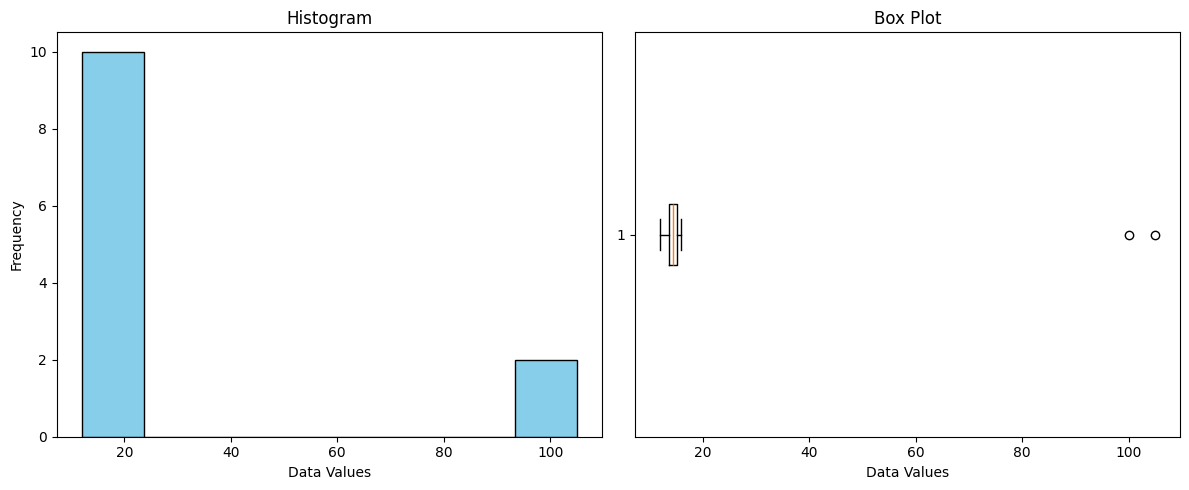

In [ ]:
# Plot Histogram and Box Plot
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(data, bins=8, color='skyblue', edgecolor='black')
plt.title('Histogram')
plt.xlabel('Data Values')
plt.ylabel('Frequency')

# Box Plot
plt.subplot(1, 2, 2)
plt.boxplot(data, vert=False)
plt.title('Box Plot')
plt.xlabel('Data Values')

plt.tight_layout()
plt.show()

### Understanding the Box Plot

The box plot shows:
- **Box**: The IQR (Q1 to Q3) - contains middle 50% of data
- **Line in box**: The median (Q2)
- **Whiskers**: Extend to smallest/largest values within 1.5×IQR
- **Dots**: Outliers (values beyond whiskers)

### Outlier Detection Rule

Values are outliers if they are:
- Less than Q1 - 1.5×IQR (lower outliers)
- Greater than Q3 + 1.5×IQR (upper outliers)

In [ ]:
# Calculate outlier boundaries
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Outlier Detection:")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"\nValues outside [{lower_bound:.2f}, {upper_bound:.2f}] are outliers")

# Find outliers
outliers = [x for x in data if x < lower_bound or x > upper_bound]
print(f"\nOutliers detected: {outliers}")

Outlier Detection:
Lower bound: 11.50
Upper bound: 17.50

Values outside [11.50, 17.50] are outliers

Outliers detected: [100, 105]


### 📝 TO DO #3: Experiment with Outliers

See how outliers affect the mean vs median:

In [ ]:
# Original data with outliers
data_with_outliers = [12, 15, 14, 13, 16, 15, 14, 15, 14, 13, 100, 105]

# TO DO: Try different outlier values
# Change the last two values (100, 105) to something else:
# Example: [12, 15, 14, 13, 16, 15, 14, 15, 14, 13, 50, 55]  # Smaller outliers
# Example: [12, 15, 14, 13, 16, 15, 14, 15, 14, 13, 200, 250]  # Bigger outliers
# Example: [12, 15, 14, 13, 16, 15, 14, 15, 14, 13, 14, 15]  # No outliers

print("With outliers:")
print(f"  Mean: {np.mean(data_with_outliers):.2f}")
print(f"  Median: {np.median(data_with_outliers):.2f}")

# Remove outliers
data_clean = [x for x in data_with_outliers if x < 20]  # Remove values > 20

print("\nWithout outliers:")
print(f"  Mean: {np.mean(data_clean):.2f}")
print(f"  Median: {np.median(data_clean):.2f}")

print("\nNotice: The mean changes dramatically with outliers, but the median stays stable!")

With outliers:
  Mean: 28.83
  Median: 14.50

Without outliers:
  Mean: 14.10
  Median: 14.00

Notice: The mean changes dramatically with outliers, but the median stays stable!


### 📝 TO DO #4: Create Your Own Dataset with Different Distributions

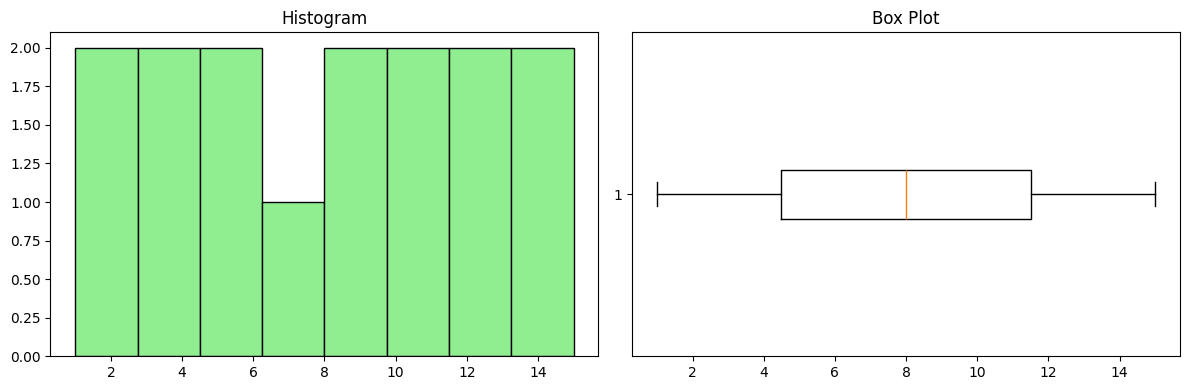

Skewness: 0.000
Mean: 8.00
Median: 8.00


In [ ]:
# TO DO: Uncomment one dataset at a time to see different distributions

# 1. Normal distribution (symmetric)
# test_data = [10, 11, 12, 12, 13, 13, 13, 14, 14, 15, 15, 16, 16, 17, 18]

# 2. Right-skewed (more small values, few large values)
# test_data = [1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 7, 8, 15, 20]

# 3. Left-skewed (more large values, few small values)
# test_data = [5, 10, 15, 17, 18, 18, 19, 19, 19, 20, 20, 20, 20, 20, 20]

# 4. Uniform distribution (all values equally likely)
test_data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

# Create visualizations
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(test_data, bins=8, color='lightgreen', edgecolor='black')
plt.title('Histogram')

plt.subplot(1, 2, 2)
plt.boxplot(test_data, vert=False)
plt.title('Box Plot')

plt.tight_layout()
plt.show()

print(f"Skewness: {skew(test_data):.3f}")
print(f"Mean: {np.mean(test_data):.2f}")
print(f"Median: {np.median(test_data):.2f}")

## Summary

### Key Concepts:

**Measures of Central Tendency:**
- Mean: Sensitive to outliers
- Median: Robust to outliers
- Mode: Most frequent value

**Measures of Spread:**
- Variance: Average squared deviation
- Standard Deviation: Square root of variance
- IQR: Q3 - Q1 (middle 50% range)

**Distribution Analysis:**
- Quartiles divide data into 4 parts
- Box plots show quartiles and outliers
- Skewness tells us about asymmetry
- Outliers: Values beyond 1.5×IQR from quartiles

### Practice Questions:

1. Why is median better than mean when you have outliers?
2. If Q1=25 and Q3=75, what values would be considered outliers?
3. What does positive skewness tell us about the data?
4. If all values in a dataset are the same, what is the standard deviation?